In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

In [4]:
#collect and clean the data
sd = yf.download("^NSEI", interval='1d')
df=sd
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2007-09-17,4518.450195,4549.049805,4482.850098,4494.649902,4494.649902,0
2007-09-18,4494.100098,4551.799805,4481.549805,4546.200195,4546.200195,0
2007-09-19,4550.250000,4739.000000,4550.250000,4732.350098,4732.350098,0
2007-09-20,4734.850098,4760.850098,4721.149902,4747.549805,4747.549805,0
2007-09-21,4752.950195,4855.700195,4733.700195,4837.549805,4837.549805,0
...,...,...,...,...,...,...
2023-10-20,19542.150391,19593.800781,19518.699219,19542.650391,19542.650391,198300
2023-10-23,19521.599609,19556.849609,19257.849609,19281.750000,19281.750000,176000
2023-10-25,19286.449219,19347.300781,19074.150391,19122.150391,19122.150391,225300


<AxesSubplot:xlabel='Date'>

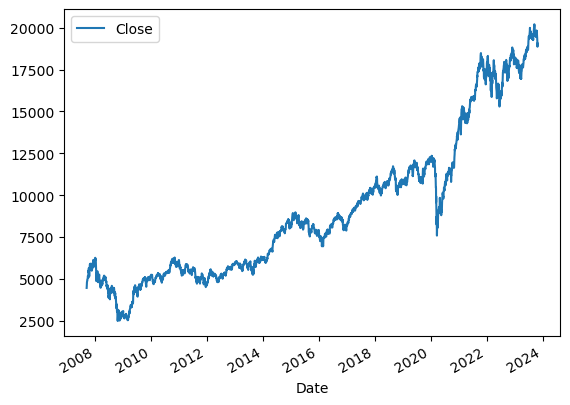

In [6]:
df.plot(y="Close")

In [18]:
#Train the model
X= df[["Open","High","Low","Volume"]]
X= X[:int(len(df)-1)]
y=df["Close"]
y= y[:int(len(df)-1)]


,Open,High,Low,Volume
Date,,,,
2007-09-17,4518.450195,4549.049805,4482.850098,0
2007-09-18,4494.100098,4551.799805,4481.549805,0
2007-09-19,4550.250000,4739.000000,4550.250000,0
2007-09-20,4734.850098,4760.850098,4721.149902,0
2007-09-21,4752.950195,4855.700195,4733.700195,0
...,...,...,...,...
2023-10-19,19545.199219,19681.800781,19512.349609,230300
2023-10-20,19542.150391,19593.800781,19518.699219,198300
2023-10-23,19521.599609,19556.849609,19257.849609,176000


In [19]:
model = RandomForestRegressor()

In [21]:
model.fit(X,y)

RandomForestRegressor()

In [23]:
#Test the model
predictions = model.predict(X)
print("The model score is:", model.score(X,y))

The model score is: 0.9999822615613276


In [24]:
new_data = df[["Open","High","Low","Volume"]].tail(1)
prediction = model.predict(new_data)
print("Thye model predicts the last row or day to be :", prediction)


Thye model predicts the last row or day to be : [18927.86177734]


new_data = df[["Open","High","Low","Volume"]]
prediction = model.predict(new_data)

In [28]:
new_data = df[["Open","High","Low","Volume"]].tail(2)
prediction = model.predict(new_data)
prediction

array([18892.97294922, 18927.86177734])

In [30]:
ret_daily = df["Close"].pct_change(periods=1)
ret_daily

Date
2007-09-17         NaN
2007-09-18    0.011469
2007-09-19    0.040946
2007-09-20    0.003212
2007-09-21    0.018957
                ...   
2023-10-20   -0.004181
2023-10-23   -0.013350
2023-10-25   -0.008277
2023-10-26   -0.013853
2023-10-27    0.010076
Name: Close, Length: 3950, dtype: float64

In [31]:
sd = yf.download("^IXIC", interval='1d')
nsdq=sd
nsdq

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1971-02-05,100.000000,100.000000,100.000000,100.000000,100.000000,0
1971-02-08,100.839996,100.839996,100.839996,100.839996,100.839996,0
1971-02-09,100.760002,100.760002,100.760002,100.760002,100.760002,0
1971-02-10,100.690002,100.690002,100.690002,100.690002,100.690002,0
1971-02-11,101.449997,101.449997,101.449997,101.449997,101.449997,0
...,...,...,...,...,...,...
2023-10-23,12930.849609,13143.219727,12848.830078,13018.330078,13018.330078,4669060000
2023-10-24,13084.990234,13170.389648,13022.849609,13139.870117,13139.870117,4604720000
2023-10-25,13039.860352,13042.519531,12804.299805,12821.219727,12821.219727,4599850000


In [32]:
nsdq_ret = nsdq["Close"].pct_change(periods=1)
nsdq_ret

Date
1971-02-05         NaN
1971-02-08    0.008400
1971-02-09   -0.000793
1971-02-10   -0.000695
1971-02-11    0.007548
                ...   
2023-10-23    0.002659
2023-10-24    0.009336
2023-10-25   -0.024251
2023-10-26   -0.017597
2023-10-27    0.003763
Name: Close, Length: 13298, dtype: float64

In [43]:
#nsdq_ret.drop(columns="Date",inplace =False)
#nsdq_ret.drop(columns=nsdq_ret['date'], inplace=True)
nsdq_ret.drop(columns=nsdq_ret.columns[1:1], inplace=True)
nsdq_ret

AttributeError: 'Series' object has no attribute 'columns'